In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 30)
print("Libraries loaded. pandas version:", pd.__version__)

Libraries loaded. pandas version: 3.0.6


In [5]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Shape of features:", X.shape)
print("Shape of target:", y.shape)

Shape of features: (569, 30)
Shape of target: (569,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

baseline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]
)
baseline.fit(X_train, y_train)

baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
print("Baseline accuracy (no PCA, 30 features):", round(baseline_acc, 4))

Baseline accuracy (no PCA, 30 features): 0.986


In [7]:
thresholds = [0.80, 0.90, 0.95, 0.99]
results = []

for threshold in thresholds:
    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=threshold)),
            ("model", LogisticRegression(max_iter=2000, random_state=42))
        ]
    )
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    n_comp = pipe.named_steps["pca"].n_components_
    acc = accuracy_score(y_test, pred)
    results.append(
        {
            "Variance threshold": threshold,
            "Number of components": n_comp,
            "Fraction of original": round(n_comp / X.shape[1], 3),
            "Accuracy": round(acc, 4)
        }
    )

df_results = pd.DataFrame(results)
df_results

,Variance threshold,Number of components,Fraction of original,Accuracy
0,0.80,5,0.167,0.965
1,0.90,7,0.233,0.965
2,0.95,10,0.333,0.979
3,0.99,17,0.567,0.986


In [8]:
print("Accuracy without PCA (30 features):", round(accuracy_score(y_test, baseline.predict(X_test)), 4))

Accuracy without PCA (30 features): 0.986


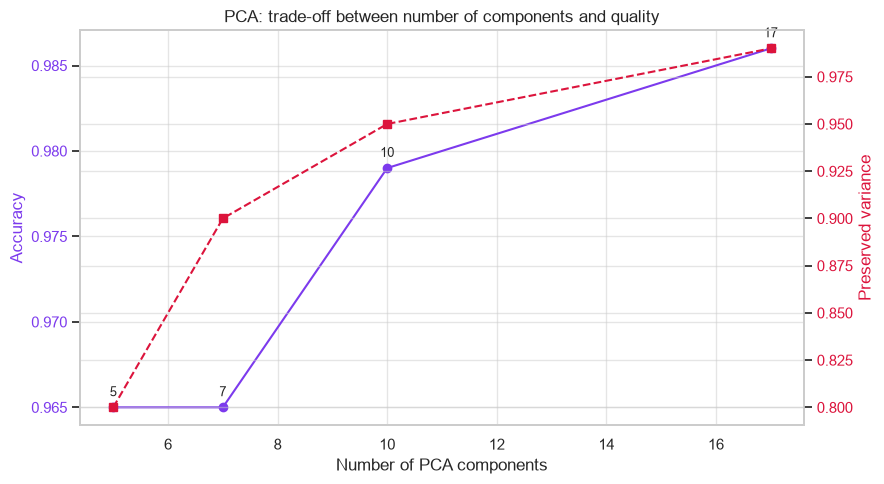

In [9]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(df_results["Number of components"], df_results["Accuracy"], marker="o", color="#7c3aed", label="Accuracy")
ax1.set_xlabel("Number of PCA components")
ax1.set_ylabel("Accuracy", color="#7c3aed")
ax1.tick_params(axis="y", labelcolor="#7c3aed")

ax2 = ax1.twinx()
ax2.plot(df_results["Number of components"], df_results["Variance threshold"], marker="s", linestyle="--", color="crimson", label="Variance threshold")
ax2.set_ylabel("Preserved variance", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")

for _, row in df_results.iterrows():
    ax1.annotate(f'{int(row["Number of components"])}', (row["Number of components"], row["Accuracy"]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

plt.title("PCA: trade-off between number of components and quality")
plt.tight_layout()
plt.show()

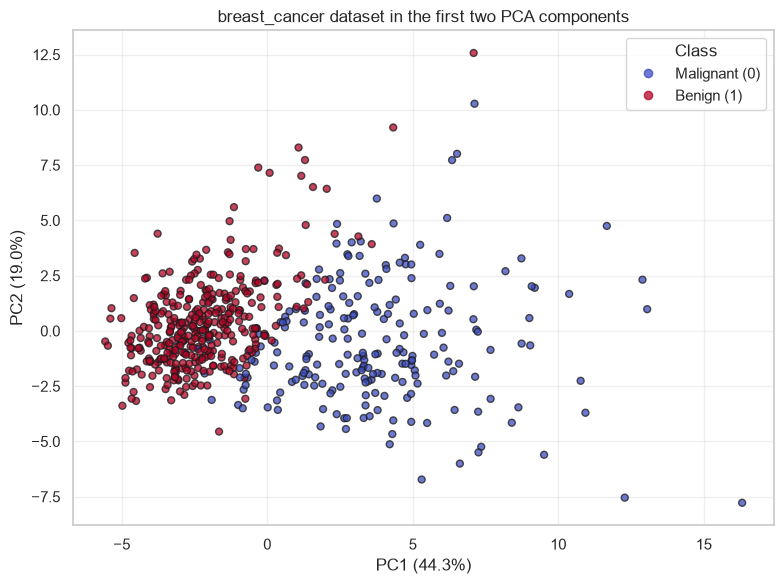

In [10]:
pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(StandardScaler().fit_transform(X))

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap="coolwarm", alpha=0.75, edgecolor="k", s=25)
plt.xlabel(f"PC1 ({pca_vis.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_vis.explained_variance_ratio_[1]:.1%})")
plt.title("breast_cancer dataset in the first two PCA components")
handles, _ = scatter.legend_elements()
plt.legend(handles, ["Malignant (0)", "Benign (1)"], title="Class")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

На гарфіку видно розділення класів, що підтверджу те, що компоненти зберігають важливу структуру, але для максимальної якості класифікації краще залишити більше компонентів.

|    | Variance threshold | Number of components | Fraction of original | Accuracy |
|---:|-------------------:|---------------------:|---------------------:|---------:|
| 0  | 0.80               | 5                    | 0.167                | 0.965    |
| 1  | 0.90               | 7                    | 0.233                | 0.965    |
| 2  | 0.95               | 10                   | 0.333                | 0.979    |
| 3  | 0.99               | 17                   | 0.567                | 0.986    |

Найкраще рішення між стисненням і якісю - поріг в 0.95, що залишає 10 компонентів із 30, тобто розмірність зменшуєтсья приблизно в 3 рпзи від початкової; точність становить 0.979, що лише на 0.007% поступаєтсья baseline без PCA (0.986); стиснення доволі суттєве, а якість класифікації залишилась майже без втрат

Порівняно з іншмии варіантами:
1. 0.99 дає точність у 0/986, як і baseline, але залишає 17 компонентів, тобто стиснення є не таким суттєвим;
2. 0.80 і 0.90 дають лише 5 і 7 компонентів відповідно, але точність падає до 0.965, що є суттєво нижче baseline; втрата якості помітна.

Отже, в залежності від приорітету:
1. Максимальна точність: 0.99 (17 компонентів);
2. Максимальне стиснення: 0.80 або 0.90 (5 і 7 компонентів відповідно);
3. Оптимальний компроміс між стисненням і якістю: 0.95 (10 компонентів, точність 0.979).